# FedAvg — Communication-Efficient Learning of Deep Networks from Decentralized Data

Reproduction of McMahan et al. (2017). FederatedAveraging on MNIST with 2NN and CNN models, IID and Non-IID partitions.


## Module 1 — Data loading and partitions


In [ ]:
# All imports in one place
import numpy as np
import torch
import random
import time
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from collections import Counter

# ---- Config (values from the paper) ----
NUM_CLIENTS = 100               # K = 100 clients
IID_PER_CLIENT = 600            # 100 x 600 = 60,000 (entire MNIST train set)
SHARD_SIZE = 300                # non-IID: 200 shards of 300 = 60,000
SHARDS_PER_CLIENT = 2           # each client gets 2 shards

# ---- Load MNIST ----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))   # MNIST mean & std
])

train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f'Train examples: {len(train_dataset)}')
print(f'Test  examples: {len(test_dataset)}')



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.06MB/s]

Train examples: 60000
Test  examples: 10000


In [ ]:
# ============================================================
# Module 1, Step 2: IID partition
# ============================================================
def iid_partition(dataset, num_clients=100):
    num_items = len(dataset) // num_clients     # 60000 // 100 = 600
    all_indices = np.random.permutation(len(dataset))
    client_indices = {}
    for k in range(num_clients):
        start = k * num_items
        end   = start + num_items
        client_indices[k] = all_indices[start:end].tolist()
    return client_indices

np.random.seed(42)
iid_clients = iid_partition(train_dataset, num_clients=100)

print(f'Number of clients: {len(iid_clients)}')
print(f'Client 0 has {len(iid_clients[0])} examples')
labels_client0 = [train_dataset[i][1] for i in iid_clients[0]]
print(f'Client 0 digit distribution: {sorted(Counter(labels_client0).items())}')
labels_client42 = [train_dataset[i][1] for i in iid_clients[42]]
print(f'Client 42 digit distribution: {sorted(Counter(labels_client42).items())}')



Number of clients: 100
Client 0 has 600 examples
Client 0 digit distribution: [(0, 68), (1, 65), (2, 56), (3, 49), (4, 67), (5, 57), (6, 51), (7, 61), (8, 60), (9, 66)]
Client 42 digit distribution: [(0, 70), (1, 58), (2, 58), (3, 57), (4, 49), (5, 46), (6, 75), (7, 58), (8, 56), (9, 73)]


In [ ]:
# ============================================================
# Module 1, Step 3: Non-IID (pathological) partition
# ============================================================
def noniid_partition(dataset, num_clients=100, num_shards=200, shard_size=300):
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    sorted_indices = np.argsort(labels)
    shards = [
        sorted_indices[s * shard_size : (s + 1) * shard_size]
        for s in range(num_shards)
    ]
    shard_order = np.random.permutation(num_shards)
    client_indices = {}
    for k in range(num_clients):
        s1 = shard_order[2 * k]
        s2 = shard_order[2 * k + 1]
        client_indices[k] = np.concatenate([shards[s1], shards[s2]]).tolist()
    return client_indices

np.random.seed(42)
noniid_clients = noniid_partition(train_dataset, num_clients=100)

print('=== Non-IID partition ===')
print(f'Number of clients: {len(noniid_clients)}')
print(f'Client 0 has {len(noniid_clients[0])} examples')
labels_c0  = [train_dataset[i][1] for i in noniid_clients[0]]
labels_c42 = [train_dataset[i][1] for i in noniid_clients[42]]
print(f'Client 0  digit distribution:  {sorted(Counter(labels_c0).items())}')
print(f'Client 42 digit distribution:  {sorted(Counter(labels_c42).items())}')



=== Non-IID partition ===
Number of clients: 100
Client 0 has 600 examples
Client 0  digit distribution:  [(0, 300), (4, 300)]
Client 42 digit distribution:  [(4, 300), (9, 300)]


In [ ]:
# ============================================================
# Module 1, Step 4: Client DataLoader helper
# ============================================================
def make_client_loader(dataset, client_indices, batch_size=10):
    subset = Subset(dataset, client_indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=True)
    return loader

# Quick test
test_loader = make_client_loader(train_dataset, noniid_clients[0], batch_size=10)
images, labels = next(iter(test_loader))
print(f'Batch image tensor shape: {images.shape}')
print(f'Batch labels:             {labels.tolist()}')
print(f"All labels in client 0's set? {set(labels.tolist()).issubset({0, 4})}")



Batch image tensor shape: torch.Size([10, 1, 28, 28])
Batch labels:             [4, 0, 0, 0, 4, 0, 4, 0, 0, 4]
All labels in client 0's set? True


## Module 2 — Models (2NN and CNN)


In [ ]:
# ============================================================
# Module 2a: The 2NN model (199,210 parameters)
# ============================================================
class TwoNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 200)
        self.fc2 = nn.Linear(200, 200)
        self.fc3 = nn.Linear(200, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = TwoNN()
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Paper says:      199,210')
print(f'Match: {total_params == 199210}')



Total parameters: 199,210
Paper says:      199,210
Match: True


In [ ]:
# ============================================================
# Module 2b: The CNN model (1,663,370 parameters)
# ============================================================
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()
        self.fc1 = nn.Linear(7 * 7 * 64, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # [B, 32, 14, 14]
        x = self.pool(self.relu(self.conv2(x)))   # [B, 64, 7, 7]
        x = x.view(x.size(0), -1)                  # [B, 3136]
        x = self.relu(self.fc1(x))                 # [B, 512]
        x = self.fc2(x)                            # [B, 10]
        return x

cnn_model = CNN()
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Paper says:      1,663,370')
print(f'Match: {total_params == 1663370}')



Total parameters: 1,663,370
Paper says:      1,663,370
Match: True


## Module 3–5 — Client, Server, and Training Loop


In [ ]:
# ============================================================
# Refactored functions — model class is a parameter
# ============================================================

def client_update(client_id, client_indices, global_weights,
                  dataset, epochs=5, batch_size=10, lr=0.01, model_cls=TwoNN):
    n_k = len(client_indices)
    local_model = model_cls()
    local_model.load_state_dict(global_weights)
    loader = make_client_loader(dataset, client_indices, batch_size=batch_size)
    optimizer = torch.optim.SGD(local_model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    local_model.train()
    for epoch in range(epochs):
        for images, labels in loader:
            optimizer.zero_grad()
            outputs = local_model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
    return local_model.state_dict(), n_k


def fedavg_round(global_weights, client_indices_map, dataset,
                 C=0.1, E=5, B=10, lr=0.01, model_cls=TwoNN):
    K = len(client_indices_map)
    m = max(int(C * K), 1)
    selected = random.sample(range(K), m)
    client_weights = []
    client_sizes = []
    for k in selected:
        trained, n_k = client_update(
            client_id=k,
            client_indices=client_indices_map[k],
            global_weights=global_weights,
            dataset=dataset,
            epochs=E, batch_size=B, lr=lr,
            model_cls=model_cls
        )
        client_weights.append(trained)
        client_sizes.append(n_k)
    total_size = sum(client_sizes)
    avg_weights = {}
    for key in global_weights.keys():
        weighted_sum = sum(
            client_weights[i][key] * client_sizes[i]
            for i in range(len(selected))
        )
        avg_weights[key] = weighted_sum / total_size
    return avg_weights


def evaluate(global_weights, test_dataset, model_cls=TwoNN):
    model = model_cls()
    model.load_state_dict(global_weights)
    model.eval()
    loader = DataLoader(test_dataset, batch_size=100, shuffle=False)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total


def run_fedavg(client_indices_map, dataset, test_dataset,
               rounds=50, C=0.1, E=5, B=10, lr=0.01, label='', model_cls=TwoNN):
    torch.manual_seed(0)
    global_model = model_cls()
    global_weights = global_model.state_dict()
    accuracies = []
    for t in range(1, rounds + 1):
        start = time.time()
        global_weights = fedavg_round(
            global_weights=global_weights,
            client_indices_map=client_indices_map,
            dataset=dataset,
            C=C, E=E, B=B, lr=lr,
            model_cls=model_cls
        )
        if t % 5 == 0 or t == 1:
            acc = evaluate(global_weights, test_dataset, model_cls=model_cls)
            accuracies.append((t, acc))
            elapsed = time.time() - start
            print(f'Round {t:3d}/{rounds}  |  Test acc: {acc:.2f}%  |  {elapsed:.1f}s')
    print(f'\nFinal accuracy ({label}): {accuracies[-1][1]:.2f}%')
    return accuracies



## Module 6 — Experiment: Effect of local epochs (E) on 2NN


In [11]:
# ============================================================
# Module 6: Varying E — the core experiment (2NN, Non-IID)
# ============================================================
print('Running experiment: E in {1, 5, 20} on Non-IID data')
print('Fixed: C=0.1, B=10, lr=0.05')
print('-' * 55)

results = {}
for E in [1, 5, 20]:
    print(f'\n>>> E = {E}')
    accs = run_fedavg(
        client_indices_map=noniid_clients,
        dataset=train_dataset,
        test_dataset=test_dataset,
        rounds=50, C=0.1, E=E, B=10, lr=0.05,
        label=f'E={E}'
    )
    results[E] = accs



Running experiment: E in {1, 5, 20} on Non-IID data
Fixed: C=0.1, B=10, lr=0.05
-------------------------------------------------------

>>> E = 1
Round   1/50  |  Test acc: 16.56%  |  5.8s
Round   5/50  |  Test acc: 66.60%  |  5.4s
Round  10/50  |  Test acc: 69.41%  |  5.2s
Round  15/50  |  Test acc: 84.89%  |  5.3s
Round  20/50  |  Test acc: 87.32%  |  5.1s
Round  25/50  |  Test acc: 89.36%  |  4.7s
Round  30/50  |  Test acc: 80.36%  |  4.3s
Round  35/50  |  Test acc: 90.90%  |  4.4s
Round  40/50  |  Test acc: 89.14%  |  4.5s
Round  45/50  |  Test acc: 88.65%  |  4.3s
Round  50/50  |  Test acc: 91.82%  |  4.6s

Final accuracy (E=1): 91.82%

>>> E = 5
Round   1/50  |  Test acc: 16.16%  |  14.6s
Round   5/50  |  Test acc: 62.28%  |  13.7s
Round  10/50  |  Test acc: 74.07%  |  13.9s
Round  15/50  |  Test acc: 85.41%  |  14.9s
Round  20/50  |  Test acc: 85.32%  |  14.7s
Round  25/50  |  Test acc: 92.02%  |  14.4s
Round  30/50  |  Test acc: 88.83%  |  14.7s
Round  35/50  |  Test acc: 93.1

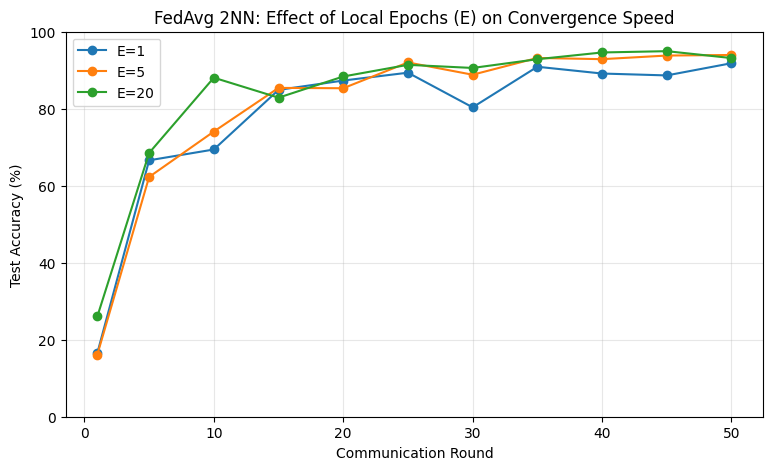

In [12]:
# ---- Plot all three E values on one graph ----
plt.figure(figsize=(9, 5))
for E, accs in results.items():
    rounds = [r for r, _ in accs]
    accs_list = [a for _, a in accs]
    plt.plot(rounds, accs_list, '-o', label=f'E={E}')
plt.xlabel('Communication Round')
plt.ylabel('Test Accuracy (%)')
plt.title('FedAvg 2NN: Effect of Local Epochs (E) on Convergence Speed')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 100)
plt.show()



## Module 6b — Same experiment on CNN


In [ ]:
# ============================================================
# Module 6b: CNN experiment — same E sweep, non-IID
# ============================================================
print('=' * 55)
print('FedAvg CNN on NON-IID partition')
print('=' * 55)

cnn_results = {}
for E in [1, 5]:
    print(f'\n>>> CNN, E = {E}')
    accs = run_fedavg(
        client_indices_map=noniid_clients,
        dataset=train_dataset,
        test_dataset=test_dataset,
        rounds=25, C=0.1, E=E, B=10, lr=0.01,
        label=f'CNN E={E}',
        model_cls=CNN
    )
    cnn_results[E] = accs



FedAvg CNN on NON-IID partition

>>> CNN, E = 1
Round   1/25  |  Test acc: 11.62%  |  29.5s
Round   5/25  |  Test acc: 51.35%  |  28.5s
Round  10/25  |  Test acc: 69.23%  |  27.4s
Round  15/25  |  Test acc: 87.11%  |  29.4s
Round  20/25  |  Test acc: 87.65%  |  28.4s
Round  25/25  |  Test acc: 90.88%  |  30.5s

Final accuracy (CNN E=1): 90.88%

>>> CNN, E = 5
Round   1/25  |  Test acc: 19.70%  |  106.0s
Round   5/25  |  Test acc: 72.94%  |  109.8s
Round  10/25  |  Test acc: 85.93%  |  103.8s
Round  15/25  |  Test acc: 92.39%  |  98.5s
Round  20/25  |  Test acc: 93.17%  |  103.3s
Round  25/25  |  Test acc: 94.62%  |  102.1s

Final accuracy (CNN E=5): 94.62%


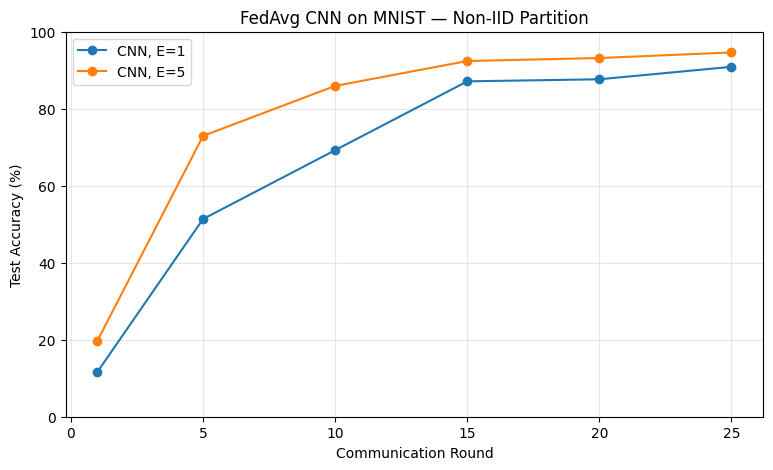

In [ ]:
# ---- Plot CNN results ----
plt.figure(figsize=(9, 5))
for E, accs in cnn_results.items():
    rounds = [r for r, _ in accs]
    accs_list = [a for _, a in accs]
    plt.plot(rounds, accs_list, '-o', label=f'CNN, E={E}')
plt.xlabel('Communication Round')
plt.ylabel('Test Accuracy (%)')
plt.title('FedAvg CNN on MNIST — Non-IID Partition')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 100)
plt.show()

